# Calibration

Convergence says the sampler explored the posterior; calibration asks whether
that posterior's uncertainty is honest. We use three lenses:
1. The probability integral transform (PIT) and;
2. quantile coverage check the posterior predictive against held-out data.
3. Simulation-based calibration (SBC) checks the inference itself across many datasets drawn from the prior.

## Load the calibration inputs

Results saved a held-out test set with its posterior predictive draws, and
the SBC ranks. Run `01_results.ipynb` first if this cell cannot find them.

In [1]:
import sys
from pathlib import Path

# The project root is the directory holding src/toynuts. From it we put the
# package on the path (no install needed) and fix one run directory the three
# notebooks share: Results writes it, Diagnostics and Calibration read it.
PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "toynuts").is_dir()),
    Path.cwd(),
)
if not any((Path(p) / "toynuts").is_dir() for p in sys.path):
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
RUN_DIR = PROJECT_ROOT / "outputs" / "notebook_run"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from toynuts.calibration import pit_values, quantile_coverage, empirical_cdf

plt.rcParams["figure.dpi"] = 110

if not RUN_DIR.exists():
    raise FileNotFoundError(f"no saved run at {RUN_DIR}; run 01_results.ipynb first")
test = pd.read_parquet(RUN_DIR / "test_set.parquet")
y_test = test["y_test"].to_numpy()
pred = pd.read_parquet(RUN_DIR / "predictive.parquet").to_numpy()   # (n_test, n_draws)
ranks = pd.read_parquet(RUN_DIR / "sbc_ranks.parquet")[["beta_0", "beta_1", "sigma"]].to_numpy()
meta = pd.read_parquet(RUN_DIR / "sbc_meta.parquet").iloc[0]
n_sims, L = int(meta["n_sims"]), int(meta["n_thinned"])
print(f"test points: {y_test.size}, predictive sample: {pred.shape}, SBC sims: {n_sims}")

test points: 400, predictive sample: (400, 2000), SBC sims: 400


## PIT (probability integral transform)

For each held-out point evaluate the posterior predictive CDF at the observed
$y$, estimated as the fraction of predictive draws at or below it. If the
predictive is calibrated these values are Uniform(0, 1).

The two panels show the same values in different units, each with a 95% band
marking where pure sampling noise would keep a calibrated model.

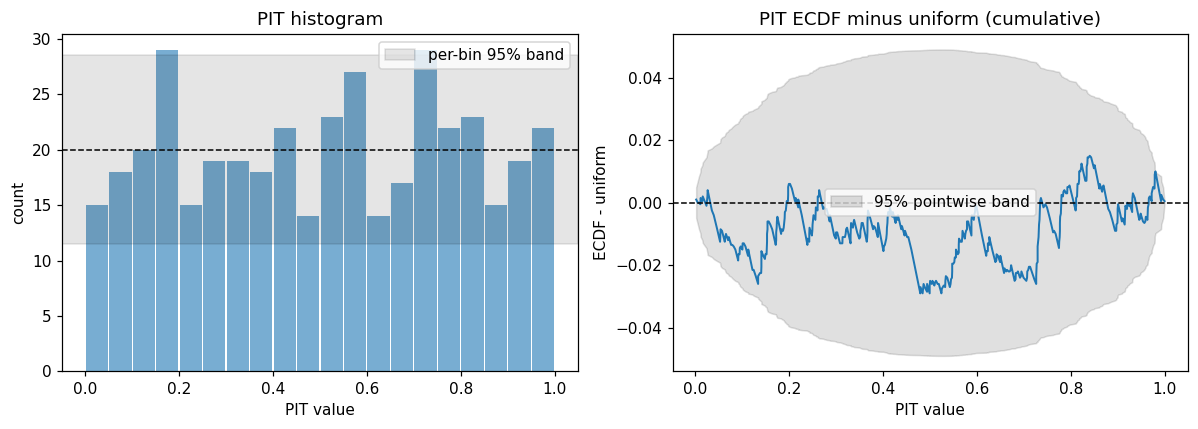

PIT mean 0.510 (uniform is 0.5), KS distance 0.029


In [2]:
pit = pit_values(y_test, pred)
xe, fe = empirical_cdf(pit)
m = pit.size

# Left: histogram counts with the uniform expectation and a per-bin 95% band.
nbins = 20
counts, edges = np.histogram(pit, bins=nbins, range=(0, 1))
centres = 0.5 * (edges[:-1] + edges[1:])
expected = m / nbins
bin_band = 1.96 * np.sqrt(m * (1 / nbins) * (1 - 1 / nbins))
# Right: pointwise 95% band for the ECDF of m uniforms, from the binomial sd.
p_grid = np.arange(1, m + 1) / m
ecdf_band = 1.96 * np.sqrt(p_grid * (1 - p_grid) / m)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(centres, counts, width=0.95 / nbins, color="C0", alpha=0.6)
axes[0].axhspan(expected - bin_band, expected + bin_band, color="k", alpha=0.1, label="per-bin 95% band")
axes[0].axhline(expected, color="k", ls="--", lw=1)
axes[0].set(title="PIT histogram", xlabel="PIT value", ylabel="count")
axes[0].legend()
axes[1].fill_between(xe, -ecdf_band, ecdf_band, color="k", alpha=0.12, label="95% pointwise band")
axes[1].plot(xe, fe - xe, color="C0", lw=1.3)
axes[1].axhline(0.0, color="k", ls="--", lw=1)
axes[1].set(title="PIT ECDF minus uniform (cumulative)", xlabel="PIT value",
            ylabel="ECDF - uniform")
axes[1].legend()
fig.tight_layout()
plt.show()
print(f"PIT mean {pit.mean():.3f} (uniform is 0.5), KS distance {np.max(np.abs(fe - xe)):.3f}")

## Quantile coverage

The same idea read as a calibration curve. For a grid of central
probabilities, build the equal-tailed predictive interval at each test point
and count how often it contains the held-out $y$. Calibrated coverage tracks
the diagonal: a nominal 90% interval should catch about 90% of the points.

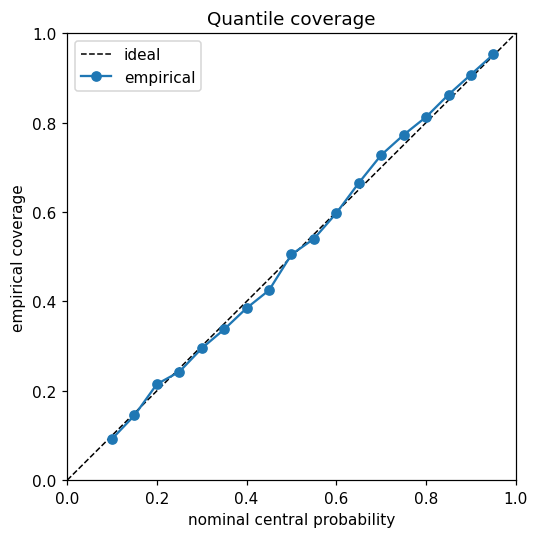

In [3]:
levels = np.linspace(0.1, 0.95, 18)
cover = quantile_coverage(y_test, pred, levels)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="ideal")
ax.plot(levels, cover, "o-", color="C0", label="empirical")
ax.set(xlabel="nominal central probability", ylabel="empirical coverage",
       title="Quantile coverage", xlim=(0, 1), ylim=(0, 1))
ax.legend()
fig.tight_layout()
plt.show()

## Simulation-based calibration (SBC)

Now, SBC tests the inference itself.

I draw a parameter set from the prior, simulate data from it,
refit, and record the rank of each true value among its posterior draws.
Averaged over many such datasets the prior and the posterior must agree, which
forces the ranks to be uniform. Systematic shapes flag a biased sampler: a
lean towards the edges means the posteriors are too narrow, a central hump too
wide. Here we only read the saved ranks and check their shape.

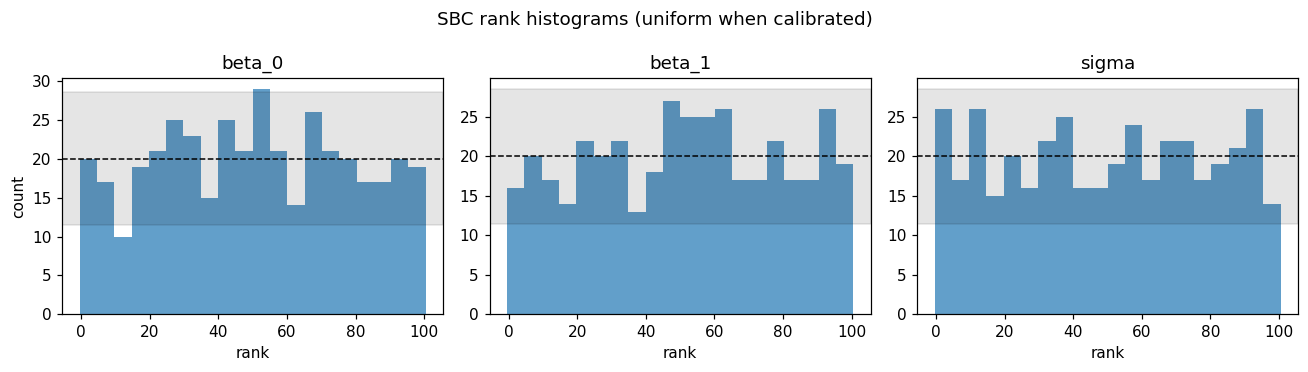

In [4]:
names = ["beta_0", "beta_1", "sigma"]
nbins = 20
expected = n_sims / nbins
band = 1.96 * np.sqrt(n_sims * (1 / nbins) * (1 - 1 / nbins))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for k, ax in enumerate(axes):
    ax.hist(ranks[:, k], bins=nbins, range=(-0.5, L + 0.5), color="C0", alpha=0.7)
    ax.axhspan(expected - band, expected + band, color="k", alpha=0.1)
    ax.axhline(expected, color="k", ls="--", lw=1)
    ax.set(title=names[k], xlabel="rank")
axes[0].set_ylabel("count")
fig.suptitle("SBC rank histograms (uniform when calibrated)")
fig.tight_layout()
plt.show()

## Verdict

A flat PIT, coverage on the diagonal and uniform SBC ranks all point the same
way: the posterior predictive is calibrated on held-out data and the sampler
recovers the prior-to-posterior map without bias. The uncertainty reported in
the Results notebook is trustworthy, not just the point estimates.